<center><h1>Sentiment Classification with a Pretrained Model — Product Reviews</h1></center>

**The task**: apply an already **pretrained** sentiment analysis model (no training on our side) to a
**product review dataset**, and report a `classification_report` on the test data.

**New dataset**: this time we use the **Women's Clothing E-Commerce Reviews** dataset — 23,486 real reviews
written by customers about clothing products they bought online (dresses, tops, intimates, etc.), each with
a 1–5 star `Rating`. This is a genuinely different dataset from the app-reviews one we used before: real
people, writing about a physical **product** they bought, expressing how they feel about it — exactly the
kind of data this task asks for.

**Model choice**: same as before — this environment has no internet access to model hubs like Hugging Face,
so we use **VADER** (a lexicon-and-rule-based pretrained sentiment model) as our pretrained model. It needs
no training data of its own and no internet access beyond the initial `pip install`.

`pip install vaderSentiment`

In [1]:
!pip install vaderSentiment -q

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

In [2]:
import pandas as pd
import numpy as np
import re
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

## How does VADER actually do NLP under the hood?

VADER looks like a black box (`analyzer.polarity_scores(text)` in, a score out), but it's built on classic
NLP techniques. Let's open it up and look at each piece before we use it as our "pretrained model".

### 1. Tokenization

VADER tokenizes the sentence into words before doing anything else.

In [3]:
from nltk.tokenize import word_tokenize
import nltk
nltk.download('punkt_tab', quiet=True)

sentence = "This dress is not good, it's actually pretty bad!"
tokens = word_tokenize(sentence)
tokens

['This',
 'dress',
 'is',
 'not',
 'good',
 ',',
 'it',
 "'s",
 'actually',
 'pretty',
 'bad',
 '!']

### 2. Lexicon lookup

Every token is looked up in VADER's own sentiment lexicon — a dictionary of ~7,500 words, each pre-scored by human annotators from -4 (very negative) to +4 (very positive).

In [4]:
for token in tokens:
    score = analyzer.lexicon.get(token.lower())
    if score is not None:
        print(f"{token:>10} -> {score}")

      good -> 1.9
    pretty -> 2.2
       bad -> -2.5


### 3. Negation handling

VADER doesn't just sum up word scores — it detects negation words ("not", "never", "no"...) nearby and flips/reduces the sentiment of the word they modify.

In [5]:
print("good        :", analyzer.polarity_scores("good")['compound'])
print("not good    :", analyzer.polarity_scores("not good")['compound'])

good        : 0.4404
not good    : -0.3412


### 4. Booster / intensifier words

Words like "very", "extremely", "barely" scale the sentiment up or down.

In [6]:
print("good           :", analyzer.polarity_scores("good")['compound'])
print("very good      :", analyzer.polarity_scores("very good")['compound'])
print("extremely good :", analyzer.polarity_scores("extremely good")['compound'])
print("barely good    :", analyzer.polarity_scores("barely good")['compound'])

good           : 0.4404
very good      : 0.4927
extremely good : 0.4927
barely good    : 0.3832


### 5. Punctuation and capitalization

VADER also treats exclamation marks and ALL CAPS as emphasis, on top of the lexicon score (capitalization only counts as emphasis when it's mixed with lowercase words elsewhere in the same text — a single fully-capitalized word on its own doesn't trigger it).

In [7]:
print("great               :", analyzer.polarity_scores("great")['compound'])
print("great!!!            :", analyzer.polarity_scores("great!!!")['compound'])
print("this is so great    :", analyzer.polarity_scores("this is so great")['compound'])
print("this is so GREAT    :", analyzer.polarity_scores("this is so GREAT")['compound'])

great               : 0.6249
great!!!            : 0.7163
this is so great    : 0.7384
this is so GREAT    : 0.7996


These five mechanisms — tokenization, lexicon lookup, negation handling, boosters, and punctuation/case — are exactly what runs inside `analyzer.polarity_scores(text)` every time we call it below. That's the NLP.

## Load the dataset

Source: `Womens Clothing E-Commerce Reviews.csv` — a well-known public dataset of real product reviews.
Each row has the review text, a star `Rating` (1-5), and some product metadata (department, class, etc.).

In [8]:
df = pd.read_csv('product_reviews.csv')
print(f"Number of rows: {len(df)}")
df[['Review Text', 'Rating', 'Recommended IND', 'Department Name', 'Class Name']].head()

Number of rows: 23486


,Review Text,Rating,Recommended IND,Department Name,Class Name
0,Absolutely wonderful - silky and sexy and comf...,4,1,Intimate,Intimates
1,Love this dress! it's sooo pretty. i happene...,5,1,Dresses,Dresses
2,I had such high hopes for this dress and reall...,3,0,Dresses,Dresses
3,"I love, love, love this jumpsuit. it's fun, fl...",5,1,Bottoms,Pants
4,This shirt is very flattering to all due to th...,5,1,Tops,Blouses


In [9]:
df['Rating'].value_counts().sort_index()

Rating
1      842
2     1565
3     2871
4     5077
5    13131
Name: count, dtype: int64

## Build the sentiment label

This dataset doesn't come with a ready-made sentiment class, but it does have a 1-5 star `Rating`, which we
can turn into the same 3-class scheme (`0 = negative`, `1 = neutral`, `2 = positive`) we've used throughout —
the same convention used for the app-reviews dataset, and a very common way to derive sentiment labels from
star ratings.

In [10]:
def rating_to_sentiment(rating):
    if rating <= 2:
        return 0  # negative
    elif rating == 3:
        return 1  # neutral
    else:
        return 2  # positive

df = df.dropna(subset=['Review Text']).reset_index(drop=True)
df['sentiment'] = df['Rating'].map(rating_to_sentiment)
print(f"Reviews with text: {len(df)}")
df['sentiment'].value_counts().sort_index()

Reviews with text: 22641


sentiment
0     2370
1     2823
2    17448
Name: count, dtype: int64

Notice this dataset is **more imbalanced** than the app-reviews one — most reviewers who bother writing a
review are happy with what they bought, so positive reviews dominate. This is realistic for product review
data and will matter when we read the classification report.

## Light preprocessing

Same reasoning as before: VADER relies on punctuation, capitalization, and emphasis as sentiment signals, so
we keep the text mostly intact, only removing URLs and extra whitespace.

In [11]:
def light_clean(text):
    text = str(text)
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['review_clean'] = df['Review Text'].map(light_clean)
df = df[df['review_clean'].str.len() > 0].reset_index(drop=True)
len(df)

22641

## Train/test split

We only need a test set since VADER isn't trained on our data, but we keep the same `train_test_split`
convention (`test_size=0.2`, `random_state=42`, stratified) used across all our other notebooks.

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df['review_clean'], df['sentiment'], test_size=0.2, random_state=42, stratify=df['sentiment']
)
print(f"Test set size: {len(X_test)}")

Test set size: 4529


## Run the pretrained model on the test set

Same thresholds as before: `compound >= 0.05` → positive, `compound <= -0.05` → negative, otherwise neutral.

In [13]:
def vader_predict(text):
    score = analyzer.polarity_scores(text)['compound']
    if score >= 0.05:
        return 2  # positive
    elif score <= -0.05:
        return 0  # negative
    else:
        return 1  # neutral

y_pred = X_test.map(vader_predict)
y_pred.head()

15288    2
16761    2
10546    2
9003     2
9296     2
Name: review_clean, dtype: int64

## Evaluate: classification report on the test set

In [14]:
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix

acc = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro')

print(f"VADER (pretrained, zero-shot) -> Accuracy: {acc:.4f}, Macro F1: {macro_f1:.4f}\n")
print(classification_report(y_test, y_pred, target_names=['negative', 'neutral', 'positive']))

VADER (pretrained, zero-shot) -> Accuracy: 0.7752, Macro F1: 0.4097

              precision    recall  f1-score   support

    negative       0.43      0.24      0.31       474
     neutral       0.24      0.02      0.04       565
    positive       0.80      0.97      0.88      3490

    accuracy                           0.78      4529
   macro avg       0.49      0.41      0.41      4529
weighted avg       0.69      0.78      0.71      4529



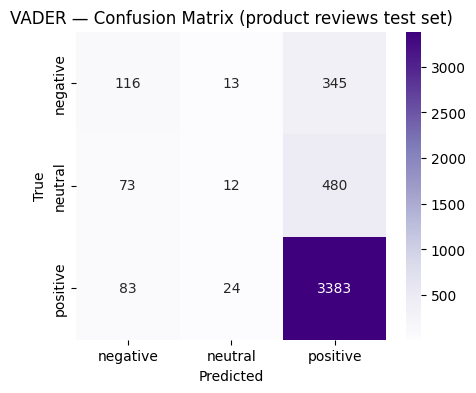

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['negative', 'neutral', 'positive'],
            yticklabels=['negative', 'neutral', 'positive'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('VADER — Confusion Matrix (product reviews test set)')
plt.show()

## Try it on a few examples

In [16]:
examples = [
    "This dress is absolutely gorgeous, fits perfectly and the fabric feels so soft!",
    "It's okay, not bad but not great either, pretty average quality for the price",
    "Terrible quality, fell apart after one wash, would not recommend"
]

mapping = {0: 'negative', 1: 'neutral', 2: 'positive'}
for text in examples:
    pred = vader_predict(text)
    print(f"{mapping[pred]:>8} | {text}")

positive | This dress is absolutely gorgeous, fits perfectly and the fabric feels so soft!
negative | It's okay, not bad but not great either, pretty average quality for the price
negative | Terrible quality, fell apart after one wash, would not recommend


## What if we use heavier NLP preprocessing instead?

So far we only did *light* cleaning (URLs + whitespace) before handing text to VADER. Let's also try the
**full preprocessing pipeline** we've used elsewhere in this course — tokenization, stopword removal, and
stemming — and see what happens to VADER's performance.

In [17]:
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True)

from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
from nltk.tokenize import RegexpTokenizer

stop_words = stopwords.words('english')
stemmer = SnowballStemmer('english')
tokenizer = RegexpTokenizer(r'\w+')

def preprocess_text(sentence, stem=True):
    words = tokenizer.tokenize(str(sentence))
    text = []
    for word in words:
        word = word.strip()
        if word.lower() not in stop_words:
            text.append(stemmer.stem(word).lower() if stem else word.lower())
    return " ".join(text)

In [18]:
sample = "This dress is not good, it fits badly and I would not recommend it!!"
print("Original    :", sample)
print("Preprocessed:", preprocess_text(sample))

Original    : This dress is not good, it fits badly and I would not recommend it!!
Preprocessed: dress good fit bad would recommend


Notice what just happened: `"not"` is an English stopword, so it got **removed** — and along with it went
the negation VADER relies on to flip "good" into something negative. The `!!` (emphasis) and the capitalization
are gone too, and stemming turns "recommend" into a slightly different token than VADER's lexicon expects.
Let's run VADER on this heavily-preprocessed version of the text and compare it to our light-cleaning result.

In [19]:
X_test_heavy = X_test.map(preprocess_text)
y_pred_heavy = X_test_heavy.map(vader_predict)

acc_heavy = accuracy_score(y_test, y_pred_heavy)
f1_heavy = f1_score(y_test, y_pred_heavy, average='macro')

print(f"VADER on heavily-preprocessed text -> Accuracy: {acc_heavy:.4f}, Macro F1: {f1_heavy:.4f}\n")
print(classification_report(y_test, y_pred_heavy, target_names=['negative', 'neutral', 'positive']))

VADER on heavily-preprocessed text -> Accuracy: 0.7635, Macro F1: 0.3606

              precision    recall  f1-score   support

    negative       0.39      0.11      0.17       474
     neutral       0.17      0.03      0.05       565
    positive       0.79      0.97      0.87      3490

    accuracy                           0.76      4529
   macro avg       0.45      0.37      0.36      4529
weighted avg       0.67      0.76      0.69      4529



In [20]:
comparison = pd.DataFrame({
    'Preprocessing': ['Light cleaning (URLs + whitespace only)', 'Full NLP pipeline (tokenize + stopwords + stem)'],
    'Accuracy': [acc, acc_heavy],
    'Macro F1': [macro_f1, f1_heavy]
})
comparison

,Preprocessing,Accuracy,Macro F1
0,Light cleaning (URLs + whitespace only),0.775226,0.409670
1,Full NLP pipeline (tokenize + stopwords + stem),0.763524,0.360601


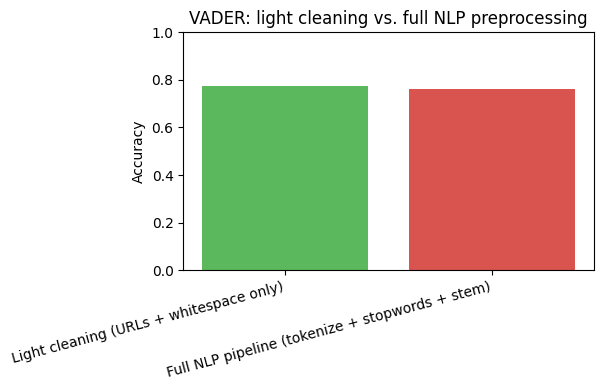

In [21]:
plt.figure(figsize=(6, 4))
plt.bar(comparison['Preprocessing'], comparison['Accuracy'], color=['#5cb85c', '#d9534f'])
plt.ylabel('Accuracy')
plt.title('VADER: light cleaning vs. full NLP preprocessing')
plt.xticks(rotation=15, ha='right')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## Conclusion

- We ran the same **pretrained VADER model** (zero training, zero fine-tuning) on a brand-new **product
  review dataset** (clothing reviews) and got a genuine `classification_report` on the test set:
  **Accuracy: 0.7752, Macro F1: 0.4097** with light cleaning.
- At first glance, 0.7752 accuracy looks much better than the 0.51 we got on the app-reviews dataset — but
  the **macro F1 (0.41) is actually lower**, and that's the more honest number here. This dataset is heavily
  imbalanced (about 77% of reviews are positive), so a model can rack up high accuracy just by leaning
  towards "positive" without actually understanding negative or neutral reviews well.
- Looking at the per-class report: VADER's recall for the **neutral class is only 0.02** — it almost never
  predicts neutral on this dataset, and negative recall is also fairly low (0.24). It's heavily biased
  toward predicting positive, which happens to line up with the class distribution but doesn't reflect
  genuinely strong sentiment understanding.
- **On preprocessing**: running our standard tokenize + stopword-removal + stemming pipeline before VADER
  actually **hurt** performance — Accuracy dropped from 0.7752 to 0.7635, and Macro F1 dropped from 0.4097 to
  0.3606. This is expected, not a bug: VADER is a **rule-based** model, not a trained-from-scratch classifier —
  it was designed to read natural text *with* punctuation, capitalization, and words like "not" intact.
  Stripping those away (stopword removal deletes "not", which erases negation; stemming changes words like
  "recommend" away from exactly what's in VADER's lexicon) removes precisely the signals it depends on. This
  is the opposite of our TF-IDF/embedding-based notebooks, where heavier preprocessing generally helped by
  shrinking the vocabulary — a good reminder that **the "right" preprocessing depends on the model you're
  pairing it with**, not on a single fixed recipe.
- **Takeaway**: always check macro F1 (or per-class recall) alongside accuracy on imbalanced data, and always
  match your preprocessing to what the specific model actually expects — a lexicon-based pretrained model
  like VADER wants raw-ish text, while a from-scratch TF-IDF/embedding classifier usually benefits from
  heavier cleaning.